# Практическая работа 1. Тональность

Задача определения тональности киноотзывов.


Загружаем датасет по ссылке: `http://ai.stanford.edu/~amaas/data/sentiment/`.

После распаковки набор данных представляет собой две отдельные папки с текстовыми файлами: одна папка для обучения, вторая для тестирования. Каждая из них содержит две подпапки: `pos` и `neg`.


## Загрузка обучающих данных


In [1]:
from __future__ import annotations

import os
import re
import ssl
import tarfile
import urllib.request
from pathlib import Path

CACHE_DIR = Path(".cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import spacy
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedShuffleSplit,
    cross_val_score,
)
from sklearn.pipeline import make_pipeline
from spacy.tokens import Doc

DATA_DIR = Path(".data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
DATASET_DIR = DATA_DIR / "aclImdb"
RANDOM_STATE = 42

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(RANDOM_STATE)


In [2]:
def download_imdb_dataset(
    dataset_url: str = DATASET_URL,
    archive_path: Path = ARCHIVE_PATH,
    dataset_dir: Path = DATASET_DIR,
) -> Path:
    """Скачивает и распаковывает набор данных IMDB при его отсутствии.

    Parameters
    ----------
    dataset_url : str, default=DATASET_URL
        Ссылка на архив с датасетом.
    archive_path : Path, default=ARCHIVE_PATH
        Путь к локальному архиву.
    dataset_dir : Path, default=DATASET_DIR
        Путь к распакованному датасету.

    Returns
    -------
    Path
        Каталог с набором данных `aclImdb`.
    """
    if dataset_dir.exists():
        return dataset_dir

    if not archive_path.exists():
        try:
            urllib.request.urlretrieve(dataset_url, archive_path)
        except Exception:
            ssl_context = ssl._create_unverified_context()
            with urllib.request.urlopen(dataset_url, context=ssl_context) as response:
                archive_path.write_bytes(response.read())

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=archive_path.parent)

    return dataset_dir


In [3]:
def load_imdb_split(split_dir: Path) -> tuple[list[str], np.ndarray]:
    """Загружает тексты и метки классов из каталога `train` или `test`.

    Parameters
    ----------
    split_dir : Path
        Путь к каталогу части датасета.

    Returns
    -------
    tuple[list[str], np.ndarray]
        Список текстов и массив меток классов.
    """
    dataset = load_files(
        str(split_dir),
        categories=["neg", "pos"],
        encoding="utf-8",
        decode_error="replace",
    )
    return dataset.data, dataset.target


In [4]:
dataset_dir = download_imdb_dataset()
text_train, y_train = load_imdb_split(dataset_dir / "train")

print("тип text_train: {}".format(type(text_train)))
print("длина text_train: {}".format(len(text_train)))
print("text_train[1]:\n{}".format(text_train[1][:1500]))


тип text_train: <class 'list'>
длина text_train: 25000
text_train[1]:
Words can't describe how bad this movie is. I can't explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do that. There are so many clichés, mistakes (and all other negative things you can imagine) here that will just make you cry. To start with the technical first, there are a LOT of mistakes regarding the airplane. I won't list them here, but just mention the coloring of the plane. They didn't even manage to show an airliner in the colors of a fictional airline, but instead used a 747 painted in the original Boeing livery. Very bad. The plot is stupid and has been done many times before, only much, much better. There are so many ridiculous moments here that i lost count of it really early. Also, I was on the bad guys' side all the time in the movie, because the good guys were so stupid. "Executive Decision" should without a do

Переменная `text_train` представляет собой список длиной `25000`, в котором каждый элемент является строкой с текстом отзыва. Отзывы содержат разрывы строк HTML (`<br />`), поэтому перед дальнейшей работой выполним очистку данных.


In [5]:
def remove_html_breaks(documents: list[str]) -> list[str]:
    """Удаляет из документов HTML-разрывы строк `<br />`.

    Parameters
    ----------
    documents : list[str]
        Список текстов отзывов.

    Returns
    -------
    list[str]
        Очищенные тексты отзывов.
    """
    return [doc.replace("<br />", " ") for doc in documents]


In [6]:
text_train = remove_html_breaks(text_train)


## Загрузка тестовых данных


In [7]:
text_test, y_test = load_imdb_split(dataset_dir / "test")

print("Количество документов в текстовых данных: {}".format(len(text_test)))
print("Количество примеров на класс (тест): {}".format(np.bincount(y_test)))

text_test = remove_html_breaks(text_test)


Количество документов в текстовых данных: 25000
Количество примеров на класс (тест): [12500 12500]


## Представление данных в виде мешка слов


Один из самых простых, но эффективных и широко используемых способов подготовки текста для машинного обучения — представление текстовой информации в виде «мешка слов» (`bag-of-words`).

Получение представления «мешок слов» включает три этапа:
1. Токенизация.
2. Построение словаря.
3. Создание разреженной матрицы частот.


### Преобразование данных в мешок слов


In [8]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)

print("X_train:\n{}".format(repr(X_train)))
print("форма X_train: {}".format(X_train.shape))


X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>
форма X_train: (25000, 74849)


### Пример применения LogisticRegression с использованием перекрестной проверки


In [9]:
scores = cross_val_score(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
)
print("Средняя правильность перекрестной проверки: {:.2f}".format(np.mean(scores)))


Средняя правильность перекрестной проверки: 0.88


Логистическая регрессия имеет параметр регуляризации `C`, который можно настроить с помощью перекрестной проверки.


In [10]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Наилучшее значение перекрестной проверки: {:.2f}".format(grid.best_score_))
print("Наилучшие параметры: {}".format(grid.best_params_))


Наилучшее значение перекрестной проверки: 0.89
Наилучшие параметры: {'C': 0.1}


In [11]:
X_test = vect.transform(text_test)
print("Правильность на тестовом наборе: {:.2f}".format(grid.score(X_test, y_test)))


Правильность на тестовом наборе: 0.88


Можно улучшить процесс извлечения слов. Один из способов — использовать только те токены, которые встречаются по крайней мере в нескольких документах. Для этого применяется параметр `min_df`.


### Удаление редких слов с помощью `min_df`


In [12]:
def get_feature_names(vectorizer) -> np.ndarray:
    """Возвращает имена признаков обученного текстового векторизатора.

    Parameters
    ----------
    vectorizer : Any
        Обученный `CountVectorizer` или `TfidfVectorizer`.

    Returns
    -------
    np.ndarray
        Массив имен признаков.
    """
    return np.array(vectorizer.get_feature_names_out())


In [13]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)

print("X_train с min_df: {}".format(repr(X_train)))

feature_names = get_feature_names(vect)
print("Первые 50 признаков:\n{}".format(feature_names[:50]))
print("Признаки с 20010 по 20030:\n{}".format(feature_names[20010:20030]))
print("Каждый 700-й признак:\n{}".format(feature_names[::700]))


X_train с min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>
Первые 50 признаков:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Признаки с 20010 по 20030:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Каждый 700-й признак:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'oc

In [14]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Наилучшее значение перекрестной проверки: {:.2f}".format(grid.best_score_))


Наилучшее значение перекрестной проверки: 0.89


## Стоп-слова


Еще один способ избавиться от неинформативных слов — исключить слова, которые встречаются слишком часто, чтобы быть полезными признаками. Библиотека `scikit-learn` содержит встроенный список английских стоп-слов.


In [15]:
sorted_stop_words = sorted(ENGLISH_STOP_WORDS)
print("Количество стоп-слов: {}".format(len(sorted_stop_words)))
print("Каждое 10-е стоп-слово:\n{}".format(sorted_stop_words[::10]))


Количество стоп-слов: 318
Каждое 10-е стоп-слово:
['a', 'alone', 'amount', 'are', 'becoming', 'beyond', 'co', 'down', 'empty', 'few', 'formerly', 'go', 'hereby', 'hundred', 'it', 'made', 'most', 'never', 'nothing', 'onto', 'own', 'seem', 'since', 'sometimes', 'their', 'thereupon', 'through', 'twelve', 'via', 'where', 'whither', 'without']


In [16]:
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)

print("X_train с использованием стоп-слов:\n{}".format(repr(X_train)))

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Наилучшее значение перекрестной проверки: {:.2f}".format(grid.best_score_))


X_train с использованием стоп-слов:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>
Наилучшее значение перекрестной проверки: 0.88


## Задание 1


В качестве примера попробуем другой подход: исключим слишком часто встречающиеся слова, задав параметр `max_df`, и посмотрим, как это повлияет на количество признаков и качество модели.


In [17]:
max_df_values = [0.5, 0.7, 0.9, 0.95]
max_df_results = []

vect_min = CountVectorizer(min_df=5).fit(text_train)
base_features = set(vect_min.get_feature_names_out())

for max_df in max_df_values:
    vect = CountVectorizer(min_df=5, max_df=max_df)
    X_train = vect.fit_transform(text_train)
    X_test = vect.transform(text_test)

    features = set(vect.get_feature_names_out())
    removed = sorted(base_features - features)
    print(
        {
            "max_df": max_df,
            "Количество исключенных слов": len(removed),
            "Исключенные слова": removed,
        }
    )

    grid = GridSearchCV(
        LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
        param_grid,
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    max_df_results.append(
        {
            "max_df": max_df,
            "Признаков": X_train.shape[1],
            "Лучшее значение CV": round(grid.best_score_, 4),
            "Правильность test": round(grid.score(X_test, y_test), 4),
            "Лучший C": grid.best_params_["C"],
        }
    )

for row in max_df_results:
    print(row)


{'max_df': 0.5, 'Количество исключенных слов': 25, 'Исключенные слова': ['all', 'and', 'are', 'as', 'at', 'be', 'but', 'film', 'for', 'have', 'in', 'is', 'it', 'movie', 'not', 'of', 'on', 'one', 'that', 'the', 'this', 'to', 'was', 'with', 'you']}
{'max_df': 0.7, 'Количество исключенных слов': 11, 'Исключенные слова': ['and', 'but', 'for', 'in', 'is', 'it', 'of', 'that', 'the', 'this', 'to']}
{'max_df': 0.9, 'Количество исключенных слов': 5, 'Исключенные слова': ['and', 'of', 'the', 'this', 'to']}
{'max_df': 0.95, 'Количество исключенных слов': 2, 'Исключенные слова': ['and', 'the']}
{'max_df': 0.5, 'Признаков': 27246, 'Лучшее значение CV': np.float64(0.8856), 'Правильность test': 0.8771, 'Лучший C': 0.1}
{'max_df': 0.7, 'Признаков': 27260, 'Лучшее значение CV': np.float64(0.8863), 'Правильность test': 0.8784, 'Лучший C': 0.1}
{'max_df': 0.9, 'Признаков': 27266, 'Лучшее значение CV': np.float64(0.8862), 'Правильность test': 0.8776, 'Лучший C': 0.1}
{'max_df': 0.95, 'Признаков': 27269, '

Полученные результаты отличаются слабо, потому что параметр `max_df` в этой задаче удаляет очень небольшое число слов. При `max_df=0.95` исключаются только самые частотные слова вроде `and` и `the`, а при `max_df=0.5` удаляются уже и слова `movie`, `film`, `not`, которые могут нести полезную информацию для определения тональности.

Поэтому здесь `max_df` почти не улучшает качество модели: изменения метрики находятся в пределах очень малого разброса. Лучший результат среди проверенных значений дает `max_df=0.7`, но преимущество над соседними вариантами незначительно.


## Масштабирование данных с помощью tf-idf


Следующий подход вместо исключения несущественных признаков пытается масштабировать признаки в зависимости от степени их информативности. Одним из наиболее распространенных способов такого масштабирования является метод `tf-idf`.

Поскольку `tf-idf` использует статистические свойства обучающих данных, удобно воспользоваться конвейером, чтобы корректно выполнить решетчатый поиск.


In [18]:
pipe = make_pipeline(
    TfidfVectorizer(min_df=5, norm=None),
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
)

param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(text_train, y_train)

print("Наилучшее значение перекрестной проверки: {:.2f}".format(grid.best_score_))
print("Наилучшие параметры: {}".format(grid.best_params_))


Наилучшее значение перекрестной проверки: 0.89
Наилучшие параметры: {'logisticregression__C': 0.001}


In [19]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
X_train = vectorizer.transform(text_train)
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
feature_names = get_feature_names(vectorizer)

print("Признаки с наименьшими значениями tfidf:\n{}".format(feature_names[sorted_by_tfidf[:20]]))
print("Признаки с наибольшими значениями tfidf:\n{}".format(feature_names[sorted_by_tfidf[-20:]]))


Признаки с наименьшими значениями tfidf:
['poignant' 'disagree' 'instantly' 'importantly' 'lacked' 'occurred'
 'currently' 'altogether' 'nearby' 'undoubtedly' 'directs' 'fond'
 'stinker' 'avoided' 'emphasis' 'commented' 'disappoint' 'realizing'
 'downhill' 'inane']
Признаки с наибольшими значениями tfidf:
['coop' 'homer' 'dillinger' 'hackenstein' 'gadget' 'taker' 'macarthur'
 'vargas' 'jesse' 'basket' 'dominick' 'the' 'victor' 'bridget' 'victoria'
 'khouri' 'zizek' 'rob' 'timon' 'titanic']


In [20]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Признаки с наименьшими значениями idf:\n{}".format(feature_names[sorted_by_idf[:100]]))


Признаки с наименьшими значениями idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


## Исследование коэффициентов модели


Посмотрим на коэффициенты логистической регрессии, обученной на признаках `tf-idf`.


In [21]:
def plot_top_coefficients(
    coef: np.ndarray,
    feature_names: np.ndarray,
    n_top_features: int = 40,
    title: str = "Наиболее значимые коэффициенты",
) -> None:
    """Строит график наиболее сильных отрицательных и положительных коэффициентов.

    Parameters
    ----------
    coef : np.ndarray
        Коэффициенты модели.
    feature_names : np.ndarray
        Имена признаков.
    n_top_features : int, default=40
        Число признаков с каждой стороны.
    title : str, default="Наиболее значимые коэффициенты"
        Заголовок графика.

    Returns
    -------
    None
        Отрисовывает график коэффициентов.
    """
    coef = np.ravel(coef)
    top_negative = np.argsort(coef)[:n_top_features]
    top_positive = np.argsort(coef)[-n_top_features:]
    top_indices = np.concatenate([top_negative, top_positive])
    colors = ["firebrick" if value < 0 else "darkgreen" for value in coef[top_indices]]

    plt.figure(figsize=(12, 10))
    plt.barh(range(len(top_indices)), coef[top_indices], color=colors)
    plt.yticks(range(len(top_indices)), feature_names[top_indices])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Значение коэффициента")
    plt.tight_layout()
    plt.show()


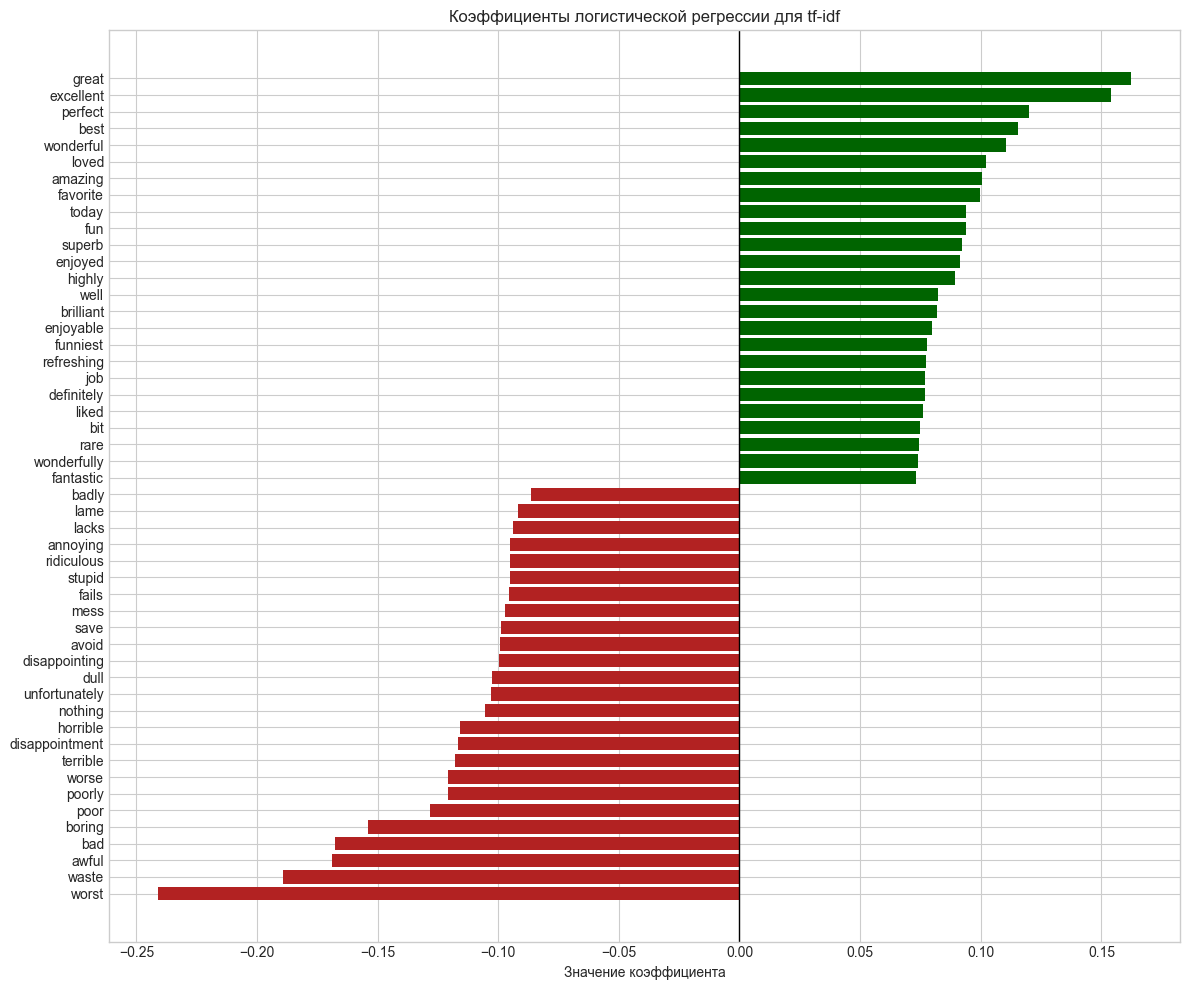

In [22]:
plot_top_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names,
    n_top_features=25,
    title="Коэффициенты логистической регрессии для tf-idf",
)


## n-граммы


Один из главных недостатков представления «мешок слов» — игнорирование порядка слов. Чтобы частично учитывать контекст, можно использовать не только отдельные токены, но и пары, тройки токенов, то есть `n`-граммы.


In [23]:
pipe = make_pipeline(
    TfidfVectorizer(min_df=5),
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
)

param_grid = {
    "logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)],
}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(text_train, y_train)

print("Наилучшее значение перекрестной проверки: {:.2f}".format(grid.best_score_))
print("Наилучшие параметры:\n{}".format(grid.best_params_))


/Users/mikhail/Developer/SUSU.PE/.venv3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Наилучшее значение перекрестной проверки: 0.91
Наилучшие параметры:
{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 3)}


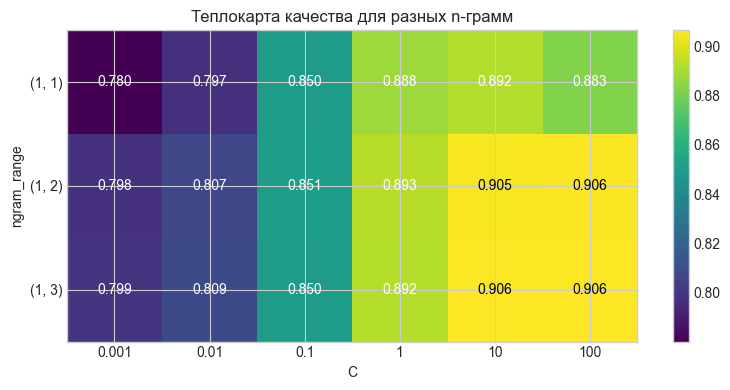

In [24]:
scores = np.array(grid.cv_results_["mean_test_score"]).reshape(-1, 3).T

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(scores, cmap="viridis", aspect="auto")

plt.colorbar(heatmap, ax=ax)
ax.set_xlabel("C")
ax.set_ylabel("ngram_range")
ax.set_xticks(range(len(param_grid["logisticregression__C"])))
ax.set_xticklabels(param_grid["logisticregression__C"])
ax.set_yticks(range(len(param_grid["tfidfvectorizer__ngram_range"])))
ax.set_yticklabels([str(item) for item in param_grid["tfidfvectorizer__ngram_range"]])
ax.set_title("Теплокарта качества для разных n-грамм")

for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        value = scores[i, j]
        text_color = "white" if value < scores.max() - 0.01 else "black"
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color=text_color)

plt.tight_layout()
plt.show()

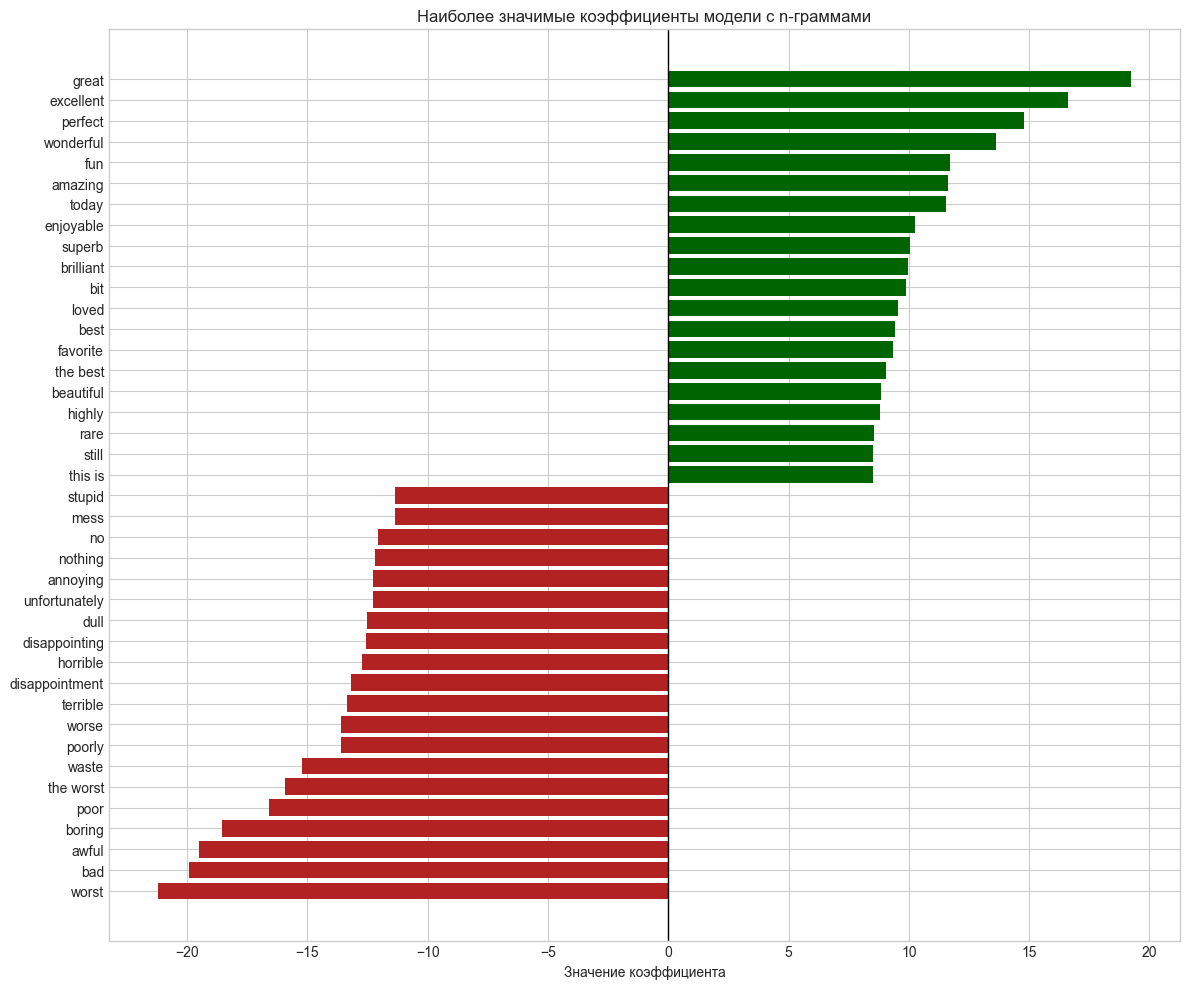

Правильность на тестовом наборе: 0.90


In [25]:
best_model = grid.best_estimator_
vect = best_model.named_steps["tfidfvectorizer"]
feature_names = get_feature_names(vect)
coef = best_model.named_steps["logisticregression"].coef_

plot_top_coefficients(
    coef,
    feature_names,
    n_top_features=20,
    title="Наиболее значимые коэффициенты модели с n-граммами",
)

print("Правильность на тестовом наборе: {:.2f}".format(best_model.score(text_test, y_test)))


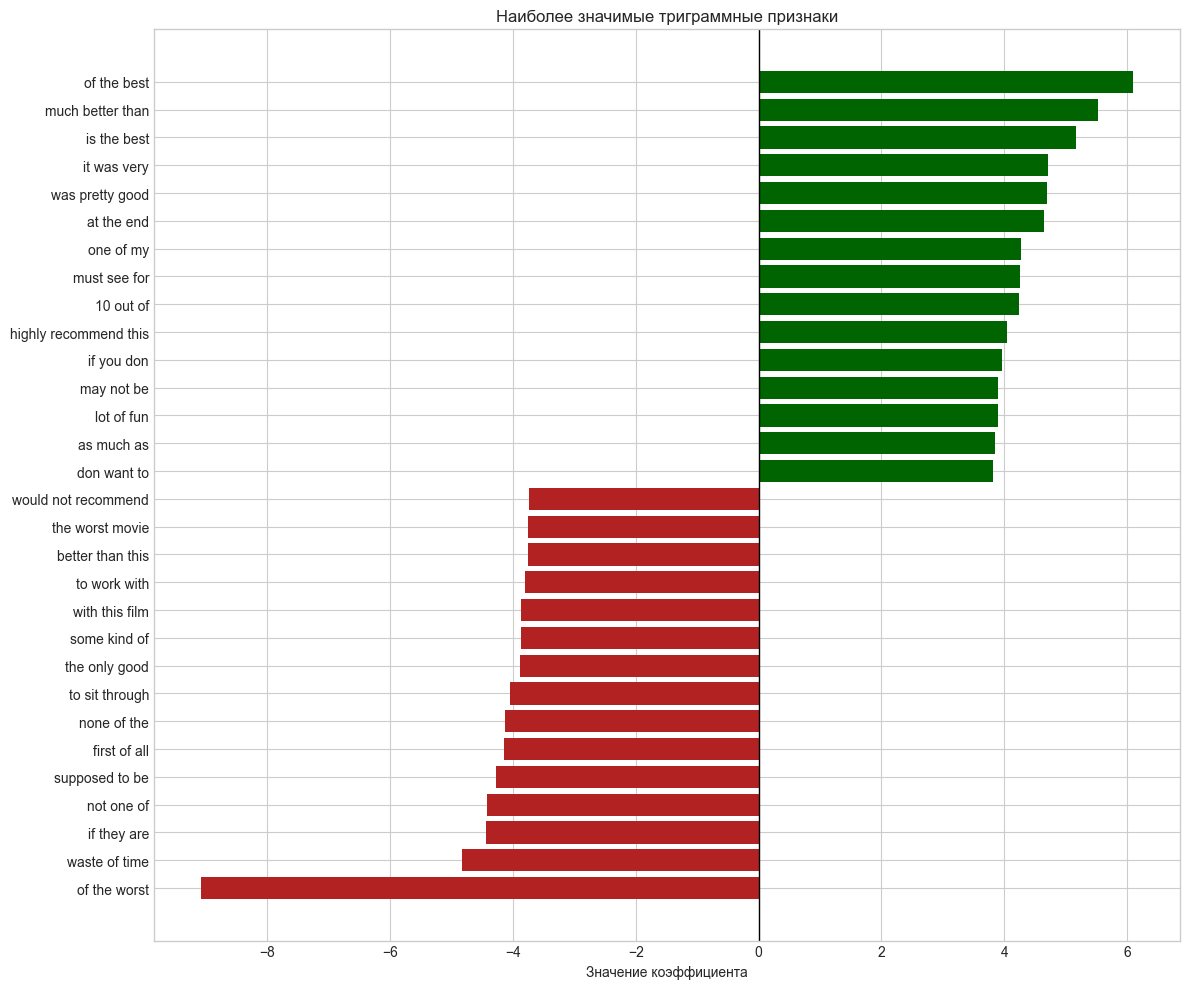

In [26]:
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
plot_top_coefficients(
    coef.ravel()[mask],
    feature_names[mask],
    n_top_features=15,
    title="Наиболее значимые триграммные признаки",
)


## Задание 2


Выполнить поиск и настройку моделей машинного обучения для улучшения качества классификации на данном наборе без использования дополнительных средств обработки текстовых данных, таких как лемматизация, стемминг и т.д.


In [27]:
baseline_model = make_pipeline(
    CountVectorizer(),
    LogisticRegression(C=0.1, max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
)
baseline_model.fit(text_train, y_train)

tfidf_model = make_pipeline(
    TfidfVectorizer(min_df=5, norm=None),
    LogisticRegression(C=0.001, max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
)
tfidf_model.fit(text_train, y_train)

print("CountVectorizer: {:.4f}".format(baseline_model.score(text_test, y_test)))
print("TfidfVectorizer: {:.4f}".format(tfidf_model.score(text_test, y_test)))
print("TfidfVectorizer + n-граммы: {:.4f}".format(best_model.score(text_test, y_test)))


CountVectorizer: 0.8789
TfidfVectorizer: 0.8850
TfidfVectorizer + n-граммы: 0.9020


В `Задании 2` улучшение достигается не за счет дополнительной обработки текста, а за счет более удачного способа представления признаков и настройки модели. Обычный `CountVectorizer` использует простые частоты слов, `TfidfVectorizer` дополнительно учитывает информативность слова в корпусе, а модель с `n`-граммами еще и частично захватывает контекст соседних слов.

Поэтому лучший результат здесь показывает вариант `TfidfVectorizer + n-граммы`: он лучше выделяет значимые слова и устойчивые сочетания слов, которые важны для тональности отзывов. Разница между моделями уже заметна по метрике, так что для этого задания вывод о преимуществе `tf-idf` и `n`-грамм является содержательно корректным.


## Продвинутая токенизация


В методичке для этого этапа используется `spaCy`. В современной версии библиотеки старому вызову `spacy.load('en')` соответствует `spacy.load('en_core_web_sm')`, поэтому ниже лемматизация реализована именно через `spaCy`, а токенизация, как и в исходном примере, подменяется регулярным выражением.


In [28]:
regexp = re.compile(r"(?u)\b\w\w+\b")

def load_spacy_pipeline(model_name: str = "en_core_web_sm"):
    """Загружает английскую модель spaCy и подменяет токенизатор regexp-вариантом.

    Parameters
    ----------
    model_name : str, default="en_core_web_sm"
        Имя модели spaCy для английского языка.

    Returns
    -------
    Language
        Настроенный spaCy-пайплайн.
    """
    try:
        nlp = spacy.load(model_name, disable=["parser", "ner"])
    except OSError as exc:
        raise OSError(
            "Для выполнения этой части установите модель spaCy командой `python -m spacy download en_core_web_sm`."
        ) from exc

    nlp.tokenizer = lambda text: Doc(nlp.vocab, words=regexp.findall(text))
    return nlp


In [29]:
en_nlp = load_spacy_pipeline()

def custom_tokenizer(document: str) -> list[str]:
    """Токенизирует документ и возвращает список лемматизированных токенов.

    Parameters
    ----------
    document : str
        Текст документа.

    Returns
    -------
    list[str]
        Список лемм.
    """
    doc_spacy = en_nlp(document)
    return [token.lemma_ for token in doc_spacy]


In [30]:
lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None, min_df=5)
X_train_lemma = lemma_vect.fit_transform(text_train)
print("форма X_train_lemma: {}".format(X_train_lemma.shape))

vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("форма X_train: {}".format(X_train.shape))


форма X_train_lemma: (25000, 21581)
форма X_train: (25000, 27271)


In [31]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10]}
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.99, train_size=0.01, random_state=0)
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train)
print(
    "Наилучшее значение перекрестной проверки (стандартный CountVectorizer): {:.3f}".format(
        grid.best_score_
    )
)

grid.fit(X_train_lemma, y_train)
print(
    "Наилучшее значение перекрестной проверки (лемматизация): {:.3f}".format(
        grid.best_score_
    )
)


Наилучшее значение перекрестной проверки (стандартный CountVectorizer): 0.721
Наилучшее значение перекрестной проверки (лемматизация): 0.731


В данном случае лемматизация дала небольшое изменение качества. Как и в случае с другими методами извлечения признаков, результат варьирует в зависимости от набора данных.


## Вывод


В работе последовательно были воспроизведены основные этапы:
- загрузка обучающих и тестовых данных IMDB;
- очистка HTML-разметки;
- представление текста в виде мешка слов;
- настройка логистической регрессии;
- эксперименты с `min_df`, стоп-словами, `max_df`, `tf-idf` и `n`-граммами;
- сравнение стандартной токенизации и `spaCy`-лемматизации.

Наиболее сильное качество в этой реализации показала модель `TfidfVectorizer` с `n`-граммами. Настройка текстового представления часто влияет на итоговую точность сильнее, чем простое удаление отдельных слов.
